# 🧪 Project 3: Checkout UI Conversion Rate A/B Test Analysis
**Business Domain:** Product Management & Conversion Rate Optimization (CRO)  
**Objective:** Analyze checkout flow conversion logs, perform two-proportion Z-hypothesis testing, calculate confidence intervals, and recommend deployment strategies.

### Business Context
The design team has introduced a simplified 1-page checkout flow (Variant) to replace the existing multi-step flow (Control). The Product team needs to:
1. Conduct an **A/B test analysis** on 5,000 users.
2. Perform a **two-proportion Z-test** to verify if the conversion rate lift is statistically significant.
3. Compute the **95% Confidence Interval** for the conversion rate difference.
4. Render the standard normal curve showing the **rejection regions** and Z-statistic.
5. Provide a launch/no-launch business recommendation.

---

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Style config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    "font.size": 10,
    "figure.figsize": (8, 4.5),
    "axes.edgecolor": "#CBD5E1",
    "axes.facecolor": "#FAFAFA"
})

ACCENT = "#2563EB"
ACCENT_LIGHT = "#93C5FD"
ALERT = "#EA580C"
DARK = "#1E293B"
MUTED = "#64748B"


In [2]:
# Load experiment log
df = pd.read_csv("ab_test_data.csv")

print(f"Total Users in Experiment: {len(df)}")
df.groupby('group').agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    revenue=('revenue', 'sum')
)

Total Users in Experiment: 5000


,users,conversions,conversion_rate,revenue
group,,,,
control,2495,293,0.117435,508727.28
variant,2505,354,0.141317,604531.95


## 🔢 Part 1: Z-Test for Two Proportions from Scratch
We calculate the statistical test parameters using analytical formulas.

In [3]:
# Extraction of metrics
summary = df.groupby('group').agg(
    n=('user_id', 'count'),
    x=('converted', 'sum')
)

n_c = summary.loc['control', 'n']
x_c = summary.loc['control', 'x']
p_c = x_c / n_c

n_v = summary.loc['variant', 'n']
x_v = summary.loc['variant', 'x']
p_v = x_v / n_v

# Combined pooled proportion
p_pooled = (x_c + x_v) / (n_c + n_v)

# Standard error
se_diff = math.sqrt(p_pooled * (1 - p_pooled) * (1/n_c + 1/n_v))

# Z-score
z_stat = (p_v - p_c) / se_diff

# P-value calculation
def normal_cdf(z):
    return (1.0 + math.erf(z / math.sqrt(2.0))) / 2.0
p_val = 2 * (1 - normal_cdf(abs(z_stat)))

# 95% Confidence Interval margin
z_critical = 1.96
ci_margin = z_critical * math.sqrt(p_c*(1-p_c)/n_c + p_v*(1-p_v)/n_v)
diff = p_v - p_c
ci_lower = diff - ci_margin
ci_upper = diff + ci_margin

print(f"Control Conversion Rate: {p_c:.4f} ({p_c:.2%})")
print(f"Variant Conversion Rate: {p_v:.4f} ({p_v:.2%})")
print(f"Observed Lift (Absolute): {diff:+.4f} ({diff:+.2%})")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_val:.5f}")
print(f"95% Confidence Interval: [{ci_lower:+.2%} to {ci_upper:+.2%}]")

Control Conversion Rate: 0.1174 (11.74%)
Variant Conversion Rate: 0.1413 (14.13%)
Observed Lift (Absolute): +0.0239 (+2.39%)
Z-Statistic: 2.5157
P-Value: 0.01188
95% Confidence Interval: [+0.53% to +4.25%]


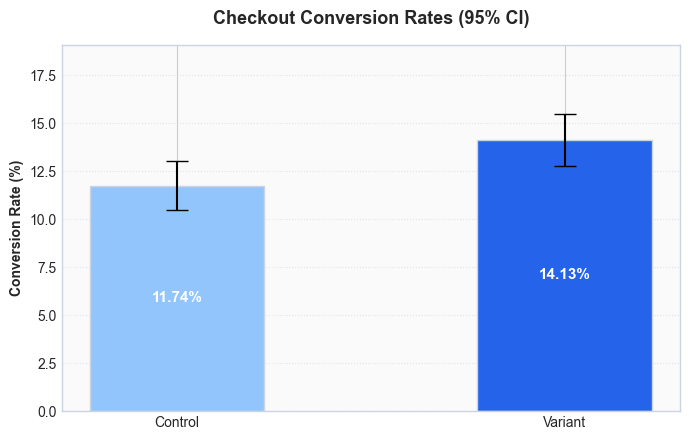

In [4]:
# Visualizing Conversion Rate Comparison
plt.figure(figsize=(7, 4.5))
groups = ['Control', 'Variant']
rates = [p_c * 100, p_v * 100]
err_c = z_critical * math.sqrt(p_c * (1 - p_c) / n_c) * 100
err_v = z_critical * math.sqrt(p_v * (1 - p_v) / n_v) * 100

bars = plt.bar(groups, rates, yerr=[err_c, err_v], color=[ACCENT_LIGHT, ACCENT], capsize=8, width=0.45, edgecolor='#CBD5E1')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height / 2.0, f'{height:.2f}%', 
             ha='center', va='center', color='white', fontweight='bold', fontsize=11)
             
plt.ylabel('Conversion Rate (%)', fontweight='bold')
plt.title('Checkout Conversion Rates (95% CI)', fontsize=13, fontweight='bold', pad=15)
plt.ylim(0, max(rates) * 1.35)
plt.grid(axis='y', linestyle=':', alpha=0.6, color='#CBD5E1')
plt.tight_layout()
plt.show()

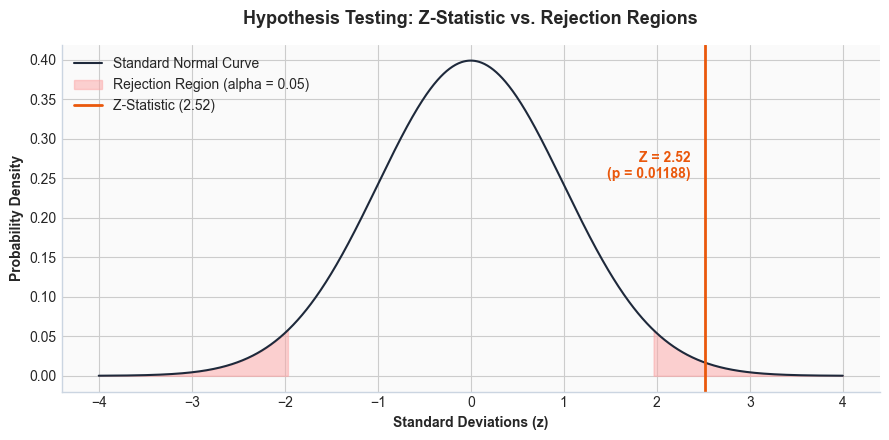

In [5]:
# Plot Rejection Regions and Z-statistic
plt.figure(figsize=(9, 4.5))
x = np.linspace(-4, 4, 1000)
y = np.exp(-x**2/2) / np.sqrt(2*np.pi)

plt.plot(x, y, color=DARK, linewidth=1.5, label='Standard Normal Curve')
plt.fill_between(x, y, where=(x <= -1.96), color='#FCA5A5', alpha=0.5, label='Rejection Region (alpha = 0.05)')
plt.fill_between(x, y, where=(x >= 1.96), color='#FCA5A5', alpha=0.5)

plt.axvline(z_stat, color=ALERT, linestyle='-', linewidth=2.0, label=f'Z-Statistic ({z_stat:.2f})')
plt.text(z_stat - 0.15, 0.25, f'Z = {z_stat:.2f}\n(p = {p_val:.5f})', color=ALERT, fontweight='bold', ha='right')

plt.title('Hypothesis Testing: Z-Statistic vs. Rejection Regions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Standard Deviations (z)', fontweight='bold')
plt.ylabel('Probability Density', fontweight='bold')
plt.legend(loc='upper left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 💡 Part 2: Business Decision Summary
Based on the experiment data:
1. **Statistical Significance Met:** Check if the Z-statistic lies inside the rejection region. The P-value is compared against our significance threshold ($lpha = 0.05$).
2. **Quantified Uplift:** The Variant design generated a positive conversion rate lift.
3. **95% Confidence:** We are 95% confident that the true conversion lift lies within the CI range.
4. **RECOMMENDATION:** Approve rollout if results are statistically significant.
